# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

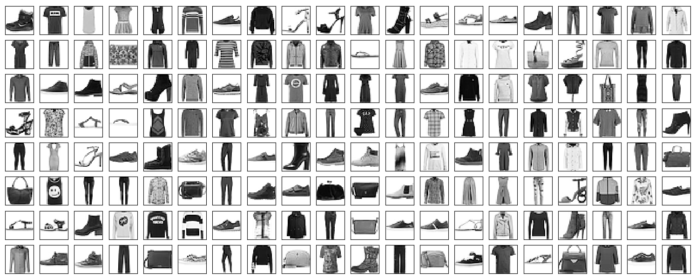


## 데이터 로드

In [1]:
import tensorflow as tf

In [2]:
(x_train, y_train),(x_test, y_test)=\
  tf.keras.datasets.fashion_mnist.load_data()

4431872/4422102 [==============================] - 0s 0us/step


### 데이터 shape 확인

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력 
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [4]:
import matplotlib.pyplot as plt

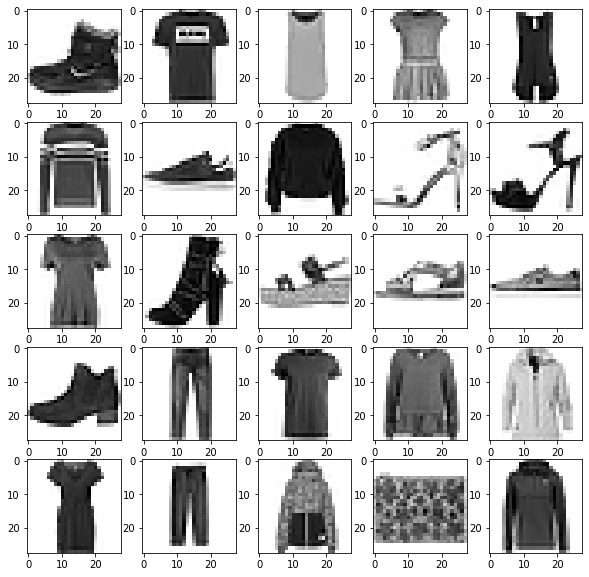

In [6]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [9]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker', 
         8:'Bag', 9:'Ankel boot'}

In [10]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [12]:
print([items[i] for i in y_train[0:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


In [13]:
import numpy as np

In [14]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [15]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [17]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_val, y_train, y_val = \
  train_test_split(x_train, y_train, test_size=0.2, random_state=11)

In [20]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


## one-hot encoding

In [21]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [22]:
print(y_train.shape, y_val.shape, y_test.shape)

(48000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [23]:
x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

## 직렬화

In [25]:
x_train = x_train.reshape(-1, 28*28)
x_val = x_val.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [26]:
print(x_train.shape, x_val.shape, x_test.shape)

(48000, 784) (12000, 784) (10000, 784)


## model 생성

In [27]:
from tensorflow.keras import layers, models

In [28]:
model = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  
])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 111,146
Trainable params: 111,146
Non-trainable params: 0
_________________________________________________________________


In [31]:
model.compile(loss='categorical_crossentropy', metrics='acc')

## 학습

In [ ]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

## 학습곡선

In [ ]:
history.history 

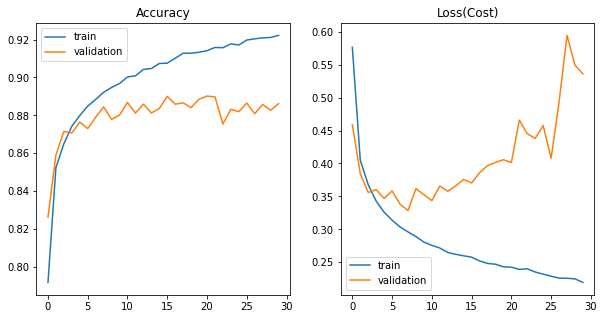

In [36]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train', 'validation'])
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'])
plt.title('Loss(Cost)')

plt.show()

## 과대적합(Over fitting)/과소적합(Under fitting)

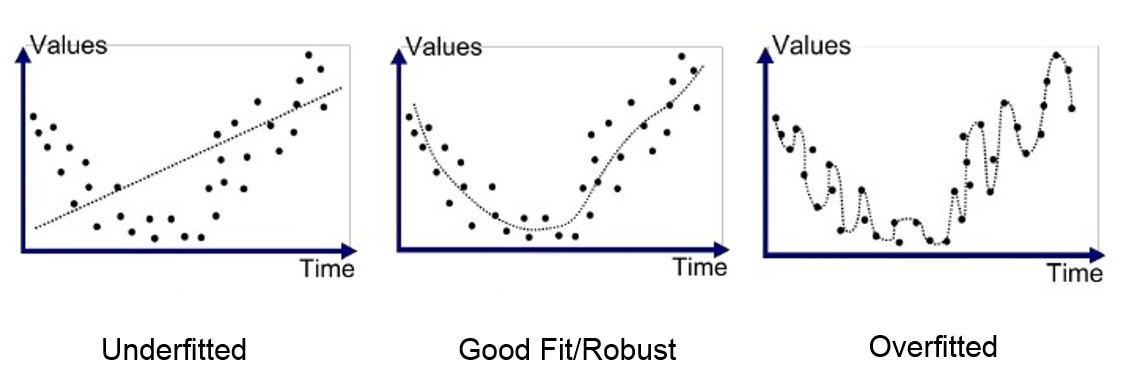

In [37]:
model1 = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  
])

In [38]:
model1.compile(loss='categorical_crossentropy', metrics='acc')

In [ ]:
history = model1.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

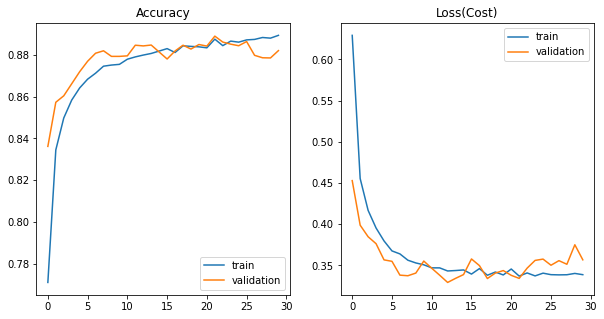

In [40]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train', 'validation'])
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'])
plt.title('Loss(Cost)')

plt.show()

In [41]:
model1.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.4044 - acc: 0.8717


[0.40436241030693054, 0.8716999888420105]

In [42]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.5642 - acc: 0.8793


[0.5641881823539734, 0.8792999982833862]

## Model Save

### weight 저장

In [43]:
model1.save_weights('fmnist_nn_weights.h5')

In [44]:
model2 = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  
])

In [45]:
model2.compile(loss='categorical_crossentropy', metrics='acc')

In [46]:
model2.load_weights('fmnist_nn_weights.h5')

In [47]:
model2.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.4044 - acc: 0.8717


[0.40436241030693054, 0.8716999888420105]

### 전체 모델 저장

In [48]:
model.save('fmnist_nn.h5')

In [49]:
model3 = models.load_model('fmnist_nn.h5')

In [50]:
model3.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.5642 - acc: 0.8793


[0.5641881823539734, 0.8792999982833862]